# IMAGINE Model Library: tutorial

This notebook walks through the Python interface of the library:

1. Evaluating a model at positions and along lines of sight
2. Evaluating on grids
3. Parameters and model variants
4. Derivatives with respect to model parameters
5. Random fields and their amplitude `rms(x)`
6. Writing your own model in Python

Conventions: positions are Galactocentric Cartesian coordinates in kpc, magnetic fields are in µG, electron densities in cm⁻³.
Per-model notebooks with plots are in `model_examples/`.

In [1]:
import numpy as np

import ImagineModels as img
from ImagineModels import plot_slice

print("version", img.__version__, "| derivatives:", img.has_autodiff, "| random fields:", img.has_fftw)

version 0.2 | derivatives: True | random fields: True


## 1. Evaluating at positions

`at_position(x, y, z)` returns the field at one position (a tuple for vector fields, a float for scalar fields).
`at_positions(x, y, z)` takes arrays and follows numpy broadcasting, e.g. to evaluate along a line of sight. Vector fields return an array of shape `(3, *shape)`.

In [2]:
jf12 = img.JF12RegularField()
print(jf12.at_position(-8.5, 0.0, 0.1))

x = np.linspace(-20.0, 20.0, 401)
line = jf12.at_positions(x, 0.0, 0.1)  # y and z are broadcast
print(line.shape)

(0.04743706873400799, 0.9059122276498338, 0.1888684388455765)
(3, 401)


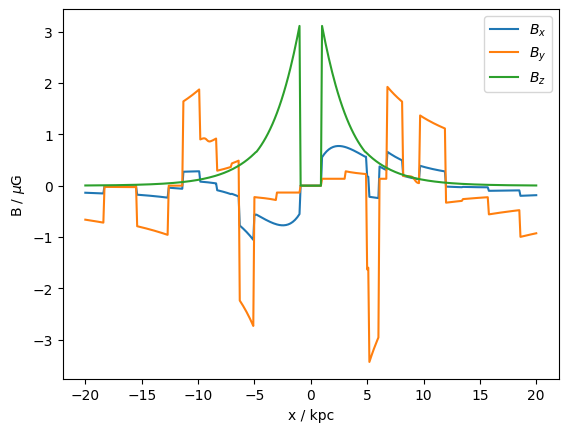

In [3]:
import matplotlib.pyplot as plt

plt.plot(x, line[0], label="$B_x$")
plt.plot(x, line[1], label="$B_y$")
plt.plot(x, line[2], label="$B_z$")
plt.xlabel("x / kpc")
plt.ylabel(r"B / $\mu$G")
plt.legend()
plt.show()

## 2. Evaluating on grids

Grids are separate objects: a `RegularGrid` (shape, reference point, increment) or an `IrregularGrid` (arbitrary x, y and z axes).
`evaluate(grid)` returns an array of shape `(3, nx, ny, nz)` for vector fields and `(nx, ny, nz)` for scalar fields.

(3, 200, 200, 1)


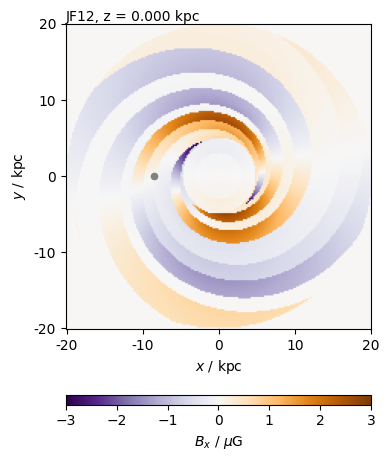

In [4]:
shape = [200, 200, 1]
refpoint = [-20.0, -20.0, 0.0]
increment = [0.2, 0.2, 0.2]
grid = img.RegularGrid(shape=shape, reference_point=refpoint, increment=increment)

b = jf12.evaluate(grid)
print(b.shape)
plot_slice(b, 2, shape, refpoint, increment, -3, 3, vec_dim=0, field_name="JF12")

In [5]:
irregular = img.IrregularGrid(x=[-10.0, -9.5, 2.0], y=[-5.0, -2.0, 0.0, 0.4], z=[-0.1, 0.0, 0.1])
print(jf12.evaluate(irregular).shape)

ymw16 = img.YMW16()
print(ymw16.evaluate(irregular).shape)  # scalar field

(3, 3, 4, 3)
(3, 4, 3)


## 3. Parameters and model variants

Every model lists its parameters in `parameter_names`. They are available as attributes and, all at once, as the dictionary `parameters`, which can also be set in part.
Other settings (switches, variant names) are separate attributes.

In [6]:
han = img.HanMagneticField()
print(han.parameter_names)
print(han.parameters)

han.A = 4.0
han.parameters = {"B_s1": 5.0, "H": 0.5}
print(han.A, han.B_s1, han.H)

['B_p', 'A', 'H', 'B_s1', 'B_s2', 'B_s3', 'B_s4', 'B_s5', 'B_s6']
{'B_p': 11.0, 'A': 5.0, 'H': 0.4, 'B_s1': 4.5, 'B_s2': -3.0, 'B_s3': 6.3, 'B_s4': -4.7, 'B_s5': 3.3, 'B_s6': -8.7}
4.0 5.0 0.5


Some models come in several published variants. `set_model` selects a variant **and** loads its published parameters; the active variant is read-only.

In [7]:
uf = img.UFMagneticField(model="expX")
print(uf.model, uf.available_models)
uf.set_model("spur")
print(uf.model, uf.fSpurCenter)

tf = img.TFMagneticField(disk_model="Dd1", halo_model="C1")
print(tf.disk_model, tf.halo_model, tf.at_position(-8.5, 0.0, 1.0))

expX ['base', 'neCL', 'expX', 'spur', 'cre10', 'synCG', 'twistX', 'nebCor']
spur 2.743428247871374
Dd1 C1 (0.5512721833743996, 11.398181388569302, -0.18146520928554866)


## 4. Derivatives

If the library was built with autodiff, `derivative(x, y, z)` returns the Jacobian of the field with respect to the parameters, with shape `(3, n)` (`(1, n)` for scalar fields).
The columns follow `active_parameters`, which defaults to all parameters; restricting it also makes the computation cheaper.

In [8]:
if img.has_autodiff:
    jacobian = jf12.derivative(-8.5, 1.0, 0.1)
    print(jacobian.shape)

    jf12.active_parameters = ["b_arm_1", "Bn", "B0_X"]
    print(dict(zip(jf12.active_parameters, jf12.derivative(-8.5, 1.0, 0.1).T)))

(3, 20)
{'b_arm_1': array([-0.,  0.,  0.]), 'Bn': array([-0.01119533, -0.09516028,  0.        ]), 'B0_X': array([-0.03474014,  0.00408707,  0.04023957])}


## 5. Random fields

Random fields are sampled on a `RegularGrid` with a seed. Their spatial amplitude is an analytic function: `rms(x, y, z)` (and `variance`) gives the expected local rms that the samples realise.
For vector fields, `rms` is the total field strength `sqrt(E|B|²)`. The spectrum only sets the correlation structure; the normalisation is done on the given grid.
With `clean_divergence = True` (default) the samples are divergence-free; for a spatially varying `rms` the total power is preserved and the local amplitude follows `rms(x)` approximately.

(3, 100, 100, 20) (100, 100, 20)
rms at the Sun: 2.4453009640107095


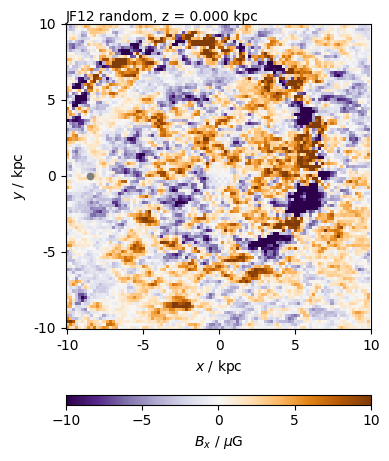

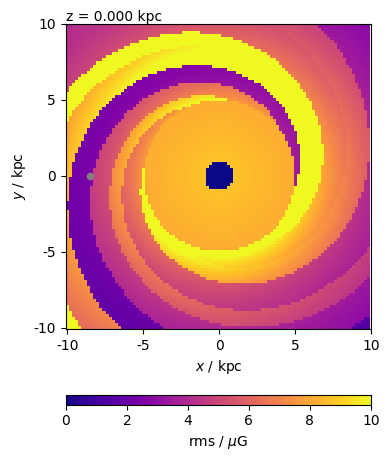

In [9]:
if img.has_fftw:
    random_field = img.JF12RandomField()
    shape = [100, 100, 20]
    refpoint = [-10.0, -10.0, -2.0]
    increment = [0.2, 0.2, 0.2]
    grid = img.RegularGrid(shape=shape, reference_point=refpoint, increment=increment)

    sample = random_field.sample(grid, seed=23)
    rms = random_field.rms(grid)
    print(sample.shape, rms.shape)
    print("rms at the Sun:", random_field.rms(-8.5, 0.0, 0.0))

    plot_slice(sample, 2, shape, refpoint, increment, -10, 10, vec_dim=0, field_name="JF12 random")
    plot_slice(rms, 2, shape, refpoint, increment, 0, 10, label=r"rms / $\mu$G")

`rms(x)` is an expectation over realisations. For a steep spectrum a few large-scale modes carry most of the variance, so the spread within a single sample can differ noticeably from `rms`; averaged over samples it converges. (Every sample has exactly zero spatial mean in `G`, since the k = 0 mode is not drawn.)

In [10]:
if img.has_fftw:
    gauss = img.GaussianScalarField()
    gauss.mu, gauss.sigma = 2.0, 0.5
    print("model mean and rms:", gauss.mean(0.0, 0.0, 0.0), gauss.rms(0.0, 0.0, 0.0))
    print("one sample:        ", gauss.sample(grid, seed=1).mean(), gauss.sample(grid, seed=1).std())
    variances = [gauss.sample(grid, seed=s).var() for s in range(20)]
    print("rms over 20 samples:", np.sqrt(np.mean(variances)))

model mean and rms: 2.0 0.5


one sample:         2.0 0.5723807352211436


rms over 20 samples: 0.5035165497108668


## 6. Writing your own model in Python

Models can be prototyped in Python by subclassing `RegularVectorField` (or `RegularScalarField`) and implementing `at_position`. Grids and `at_positions` then work as for the built-in models (evaluation calls back into Python, so this is slower than a C++ model).

In [11]:
class Toroidal(img.RegularVectorField):
    def __init__(self, b0=2.0):
        super().__init__()
        self.b0 = b0

    def at_position(self, x, y, z):
        r = np.hypot(x, y)
        if r == 0.0:
            return [0.0, 0.0, 0.0]
        return [-self.b0 * y / r, self.b0 * x / r, 0.0]


toroidal = Toroidal()
print(toroidal.at_position(-8.5, 0.0, 0.0))
print(
    toroidal.evaluate(
        img.RegularGrid(shape=[10, 10, 1], reference_point=[-5.0, -5.0, 0.0], increment=[1.0, 1.0, 1.0])
    ).shape
)

[np.float64(-0.0), np.float64(-2.0), 0.0]
(3, 10, 10, 1)
